In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Load Dataset

In [9]:
df = pd.read_csv("student-scores.csv")

In [11]:
df.head()

,id,first_name,last_name,email,gender,part_time_job,absence_days,extracurricular_activities,weekly_self_study_hours,career_aspiration,math_score,history_score,physics_score,chemistry_score,biology_score,english_score,geography_score
0,1,Paul,Casey,paul.casey.1@gslingacademy.com,male,False,3,False,27,Lawyer,73,81,93,97,63,80,87
1,2,Danielle,Sandoval,danielle.sandoval.2@gslingacademy.com,female,False,2,False,47,Doctor,90,86,96,100,90,88,90
2,3,Tina,Andrews,tina.andrews.3@gslingacademy.com,female,False,9,True,13,Government Officer,81,97,95,96,65,77,94
3,4,Tara,Clark,tara.clark.4@gslingacademy.com,female,False,5,False,3,Artist,71,74,88,80,89,63,86
4,5,Anthony,Campos,anthony.campos.5@gslingacademy.com,male,False,5,False,10,Unknown,84,77,65,65,80,74,76


# Data cleaning and preparation

In [13]:
print(df.isnull().sum())

id                            0
first_name                    0
last_name                     0
email                         0
gender                        0
part_time_job                 0
absence_days                  0
extracurricular_activities    0
weekly_self_study_hours       0
career_aspiration             0
math_score                    0
history_score                 0
physics_score                 0
chemistry_score               0
biology_score                 0
english_score                 0
geography_score               0
dtype: int64


In [15]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   id                          2000 non-null   int64 
 1   first_name                  2000 non-null   object
 2   last_name                   2000 non-null   object
 3   email                       2000 non-null   object
 4   gender                      2000 non-null   object
 5   part_time_job               2000 non-null   bool  
 6   absence_days                2000 non-null   int64 
 7   extracurricular_activities  2000 non-null   bool  
 8   weekly_self_study_hours     2000 non-null   int64 
 9   career_aspiration           2000 non-null   object
 10  math_score                  2000 non-null   int64 
 11  history_score               2000 non-null   int64 
 12  physics_score               2000 non-null   int64 
 13  chemistry_score             2000 non-null   int6

In [17]:
df.columns = [col.strip().lower().replace(" ", "_") for col in df.columns]

In [19]:
df.head()

,id,first_name,last_name,email,gender,part_time_job,absence_days,extracurricular_activities,weekly_self_study_hours,career_aspiration,math_score,history_score,physics_score,chemistry_score,biology_score,english_score,geography_score
0,1,Paul,Casey,paul.casey.1@gslingacademy.com,male,False,3,False,27,Lawyer,73,81,93,97,63,80,87
1,2,Danielle,Sandoval,danielle.sandoval.2@gslingacademy.com,female,False,2,False,47,Doctor,90,86,96,100,90,88,90
2,3,Tina,Andrews,tina.andrews.3@gslingacademy.com,female,False,9,True,13,Government Officer,81,97,95,96,65,77,94
3,4,Tara,Clark,tara.clark.4@gslingacademy.com,female,False,5,False,3,Artist,71,74,88,80,89,63,86
4,5,Anthony,Campos,anthony.campos.5@gslingacademy.com,male,False,5,False,10,Unknown,84,77,65,65,80,74,76


# Descriptive Analysis

In [21]:
df.describe()

,id,absence_days,weekly_self_study_hours,math_score,history_score,physics_score,chemistry_score,biology_score,english_score,geography_score
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000
mean,1000.500000,3.665500,17.755500,83.452000,80.332000,81.336500,79.995000,79.58150,81.277500,80.888000
std,577.494589,2.629271,12.129604,13.224906,12.736046,12.539453,12.777895,13.72219,12.027087,11.637705
min,1.000000,0.000000,0.000000,40.000000,50.000000,50.000000,50.000000,30.00000,50.000000,60.000000
25%,500.750000,2.000000,5.000000,77.000000,69.750000,71.000000,69.000000,69.00000,72.000000,71.000000
50%,1000.500000,3.000000,18.000000,87.000000,82.000000,83.000000,81.000000,81.00000,83.000000,81.000000
75%,1500.250000,5.000000,28.000000,93.000000,91.000000,92.000000,91.000000,91.00000,91.000000,91.000000
max,2000.000000,10.000000,50.000000,100.000000,100.000000,100.000000,100.000000,100.00000,99.000000,100.000000


In [34]:
print(df.columns.tolist())

['id', 'first_name', 'last_name', 'email', 'gender', 'part_time_job', 'absence_days', 'extracurricular_activities', 'weekly_self_study_hours', 'career_aspiration', 'math_score', 'history_score', 'physics_score', 'chemistry_score', 'biology_score', 'english_score', 'geography_score']


In [40]:
# Strip spaces and convert to lowercase with underscores
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print(df.columns.tolist())

['id', 'first_name', 'last_name', 'email', 'gender', 'part_time_job', 'absence_days', 'extracurricular_activities', 'weekly_self_study_hours', 'career_aspiration', 'math_score', 'history_score', 'physics_score', 'chemistry_score', 'biology_score', 'english_score', 'geography_score']


In [44]:
subjects = ['math_score', 'history_score', 'physics_score', 
            'chemistry_score', 'biology_score', 'english_score', 'geography_score']

for subject in subjects:
    avg = df[subject].mean()
    print(f"Average {subject.replace('_', ' ').title()}: {avg:.2f}")

Average Math Score: 83.45
Average History Score: 80.33
Average Physics Score: 81.34
Average Chemistry Score: 80.00
Average Biology Score: 79.58
Average English Score: 81.28
Average Geography Score: 80.89


# Bar chart of subject averages

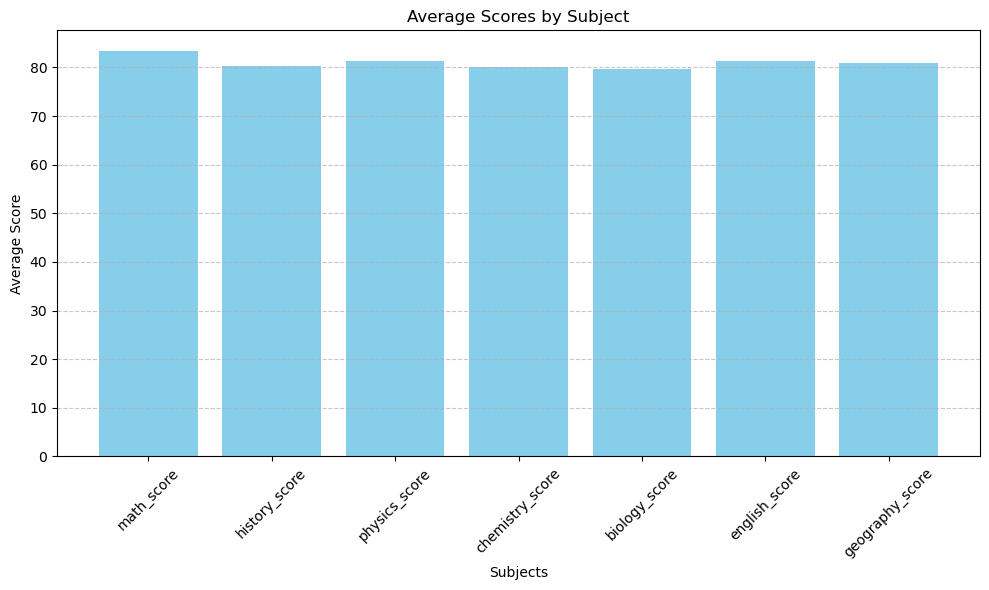

In [47]:
import matplotlib.pyplot as plt

# Calculate averages
averages = {subject: df[subject].mean() for subject in subjects}

# Plot
plt.figure(figsize=(10, 6))
plt.bar(averages.keys(), averages.values(), color='skyblue')
plt.title("Average Scores by Subject")
plt.xlabel("Subjects")
plt.ylabel("Average Score")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Data Visualization

In [50]:
# a.distribution of scores

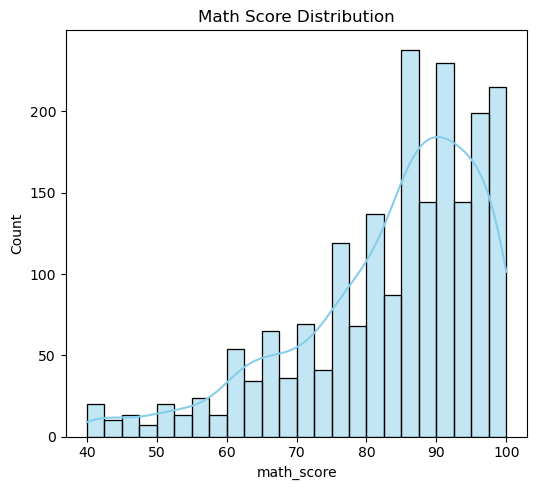

In [54]:
plt.figure(figsize=(15, 5))

for i, subject in enumerate(['math_score']):
    plt.subplot(1, 3, i+1)
    sns.histplot(df[subject], kde=True, color='skyblue')
    plt.title(f'{subject.replace("_", " ").title()} Distribution')

plt.tight_layout()
plt.show()

In [56]:
# b.Boxplot for outliers

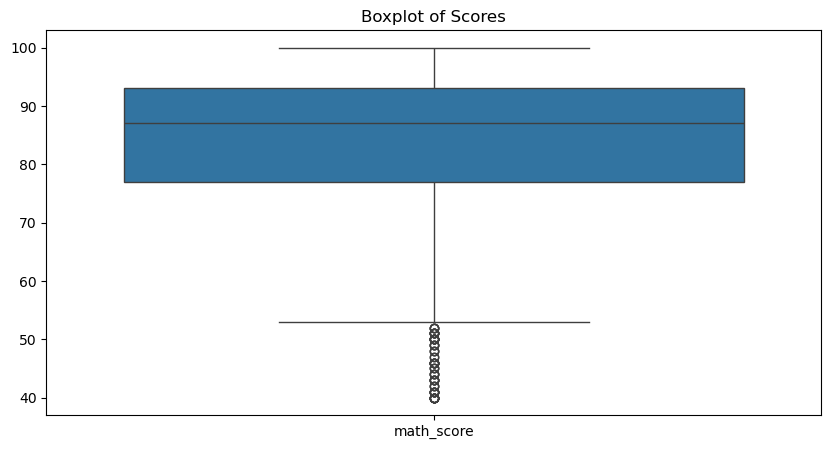

In [60]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[['math_score']])
plt.title('Boxplot of Scores')
plt.show()

In [69]:
# highest and lowest scoring students per subjects

In [67]:
for subject in subjects:
    highest = df.loc[df[subject].idxmax()]
    lowest = df.loc[df[subject].idxmin()]
    print(f"\n📘 {subject.replace('_', ' ').title()}:")
    print(f"  🔼 Highest: {highest['first_name']} {highest['last_name']} - {highest[subject]}")
    print(f"  🔽 Lowest: {lowest['first_name']} {lowest['last_name']} - {lowest[subject]}")


📘 Math Score:
  🔼 Highest: Tim Nichols - 100
  🔽 Lowest: Katherine Moore - 40

📘 History Score:
  🔼 Highest: Kelly Wade - 100
  🔽 Lowest: Roger Wiley - 50

📘 Physics Score:
  🔼 Highest: Clinton Randolph - 100
  🔽 Lowest: Kenneth Davis - 50

📘 Chemistry Score:
  🔼 Highest: Danielle Sandoval - 100
  🔽 Lowest: Jesus Rasmussen - 50

📘 Biology Score:
  🔼 Highest: Elizabeth Martin - 100
  🔽 Lowest: Carol Hill - 30

📘 English Score:
  🔼 Highest: Jennifer Garcia - 99
  🔽 Lowest: Robert Dougherty - 50

📘 Geography Score:
  🔼 Highest: Angela Rios - 100
  🔽 Lowest: Courtney Perry - 60


# correlation analysis

C:\Users\ACER\AppData\Local\Temp\ipykernel_17572\2297920453.py:7: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ACER\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


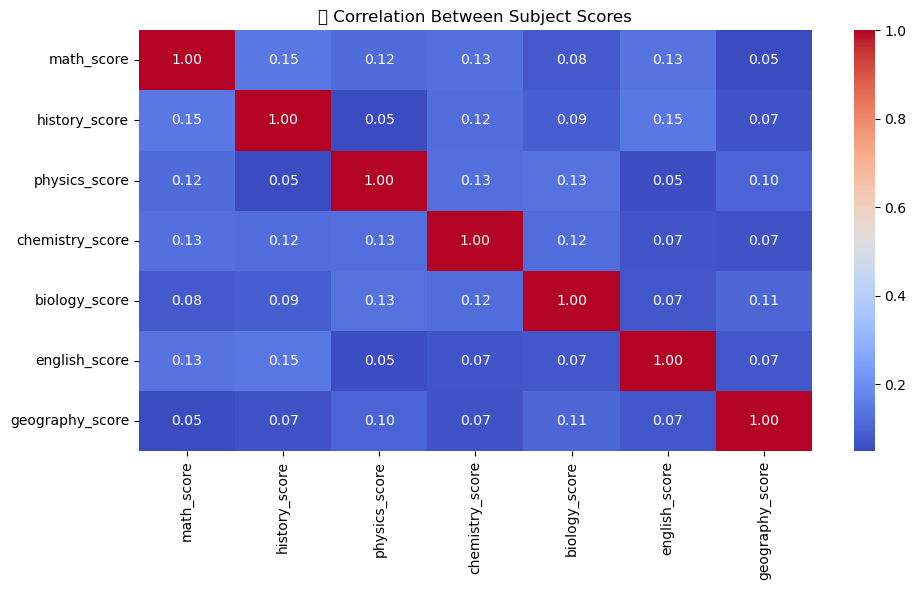

In [71]:
# Correlation matrix
corr = df[subjects].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("📈 Correlation Between Subject Scores")
plt.tight_layout()
plt.show()

C:\Users\ACER\AppData\Local\Temp\ipykernel_17572\2851674347.py:12: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ACER\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


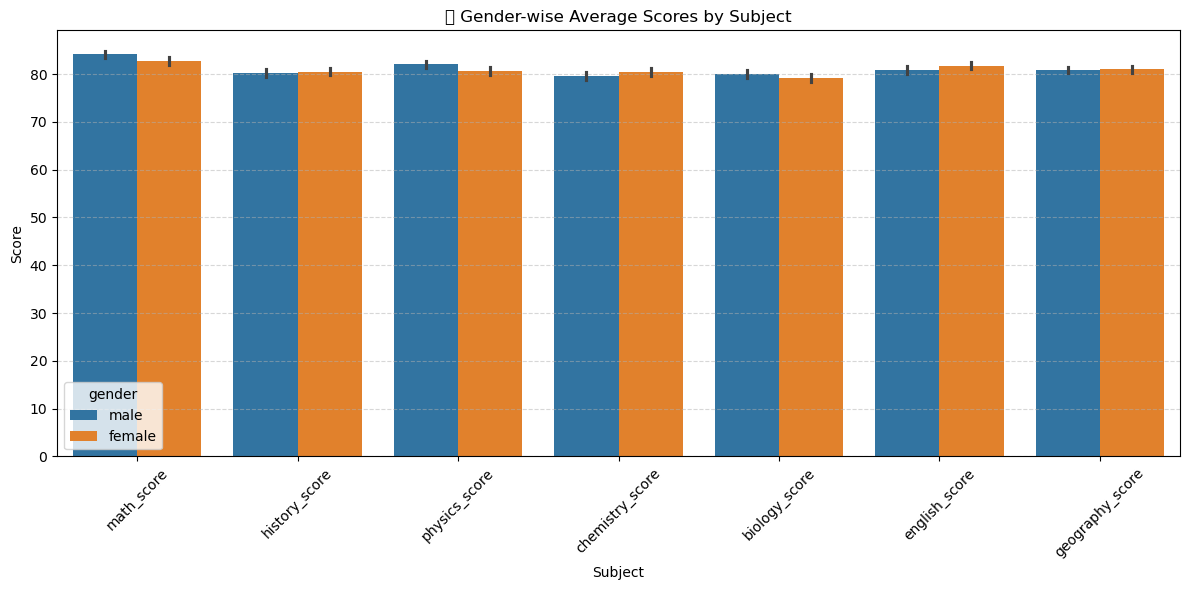

In [73]:
import seaborn as sns

# Melt the DataFrame to long format
melted_df = df.melt(id_vars=['gender'], value_vars=subjects,
                    var_name='Subject', value_name='Score')

plt.figure(figsize=(12, 6))
sns.barplot(data=melted_df, x='Subject', y='Score', hue='gender')
plt.title("📊 Gender-wise Average Scores by Subject")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

C:\Users\ACER\AppData\Local\Temp\ipykernel_17572\2354107108.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='total_score', y=top10['first_name'] + ' ' + top10['last_name'], data=top10, palette='viridis')
C:\Users\ACER\AppData\Local\Temp\ipykernel_17572\2354107108.py:10: UserWarning: Glyph 127941 (\N{SPORTS MEDAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ACER\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127941 (\N{SPORTS MEDAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


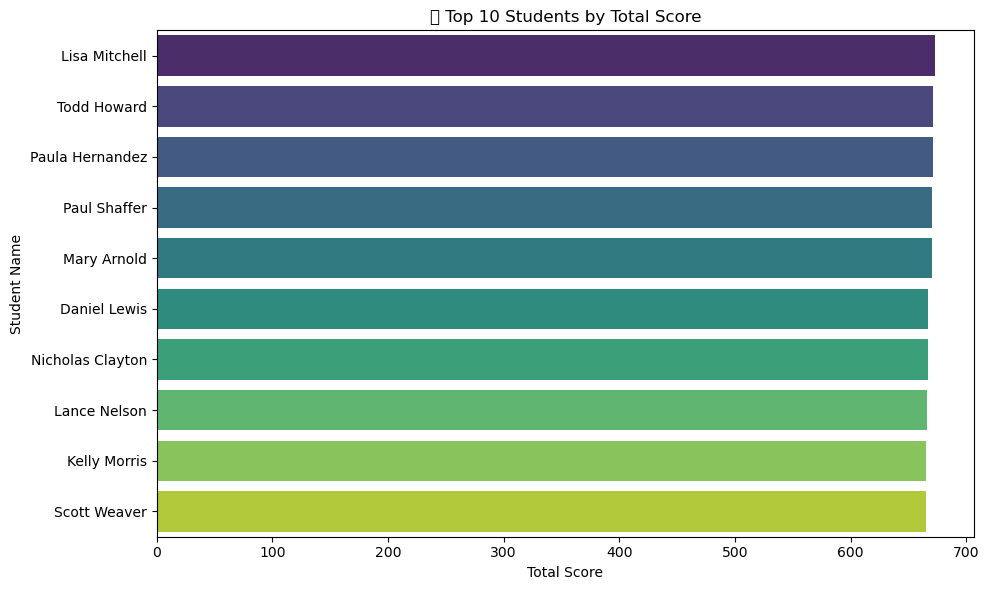

In [75]:
df['total_score'] = df[subjects].sum(axis=1)

top10 = df.sort_values(by='total_score', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='total_score', y=top10['first_name'] + ' ' + top10['last_name'], data=top10, palette='viridis')
plt.title("🏅 Top 10 Students by Total Score")
plt.xlabel("Total Score")
plt.ylabel("Student Name")
plt.tight_layout()
plt.show()

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [6]:
df = pd.read_csv("student-scores.csv")

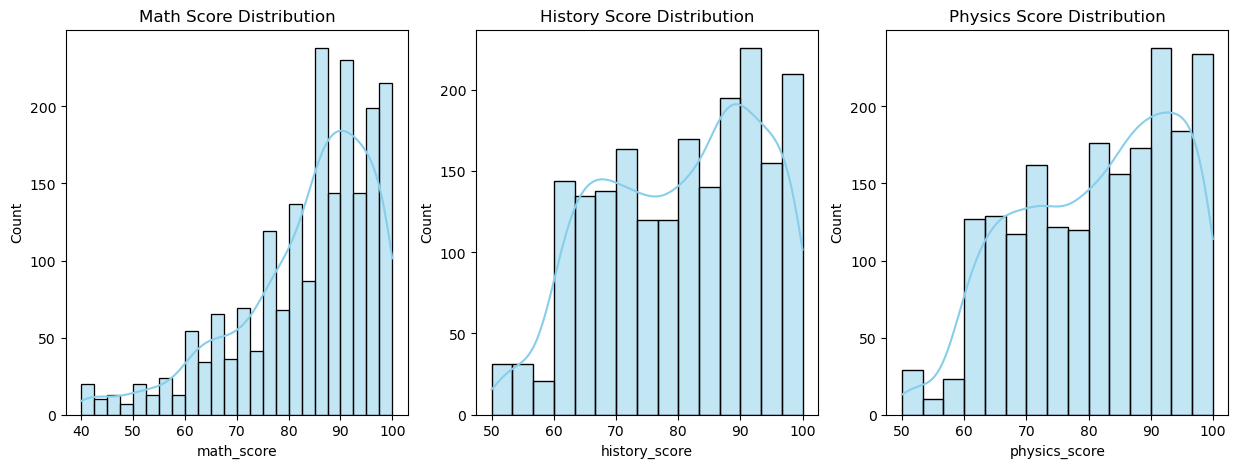

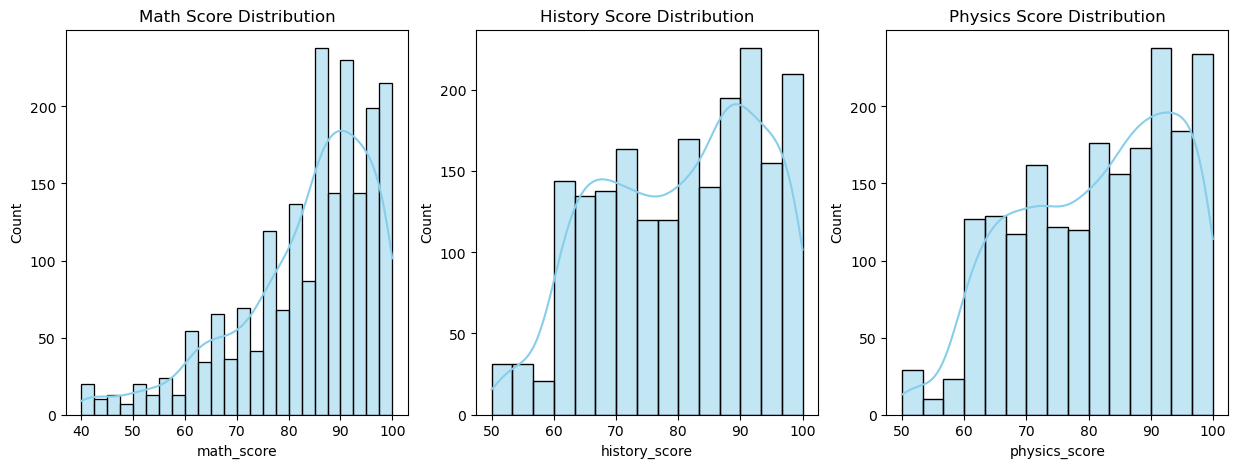

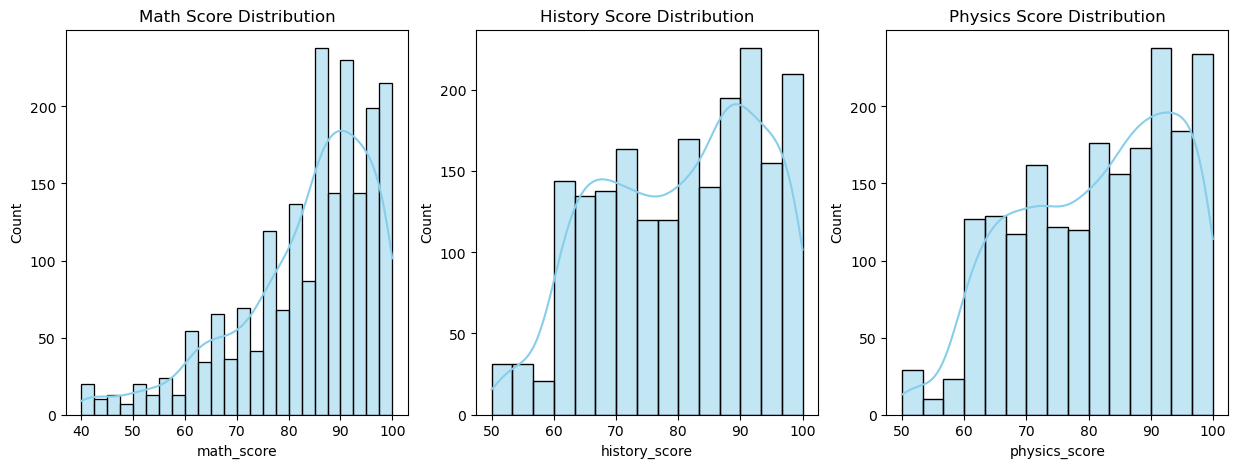

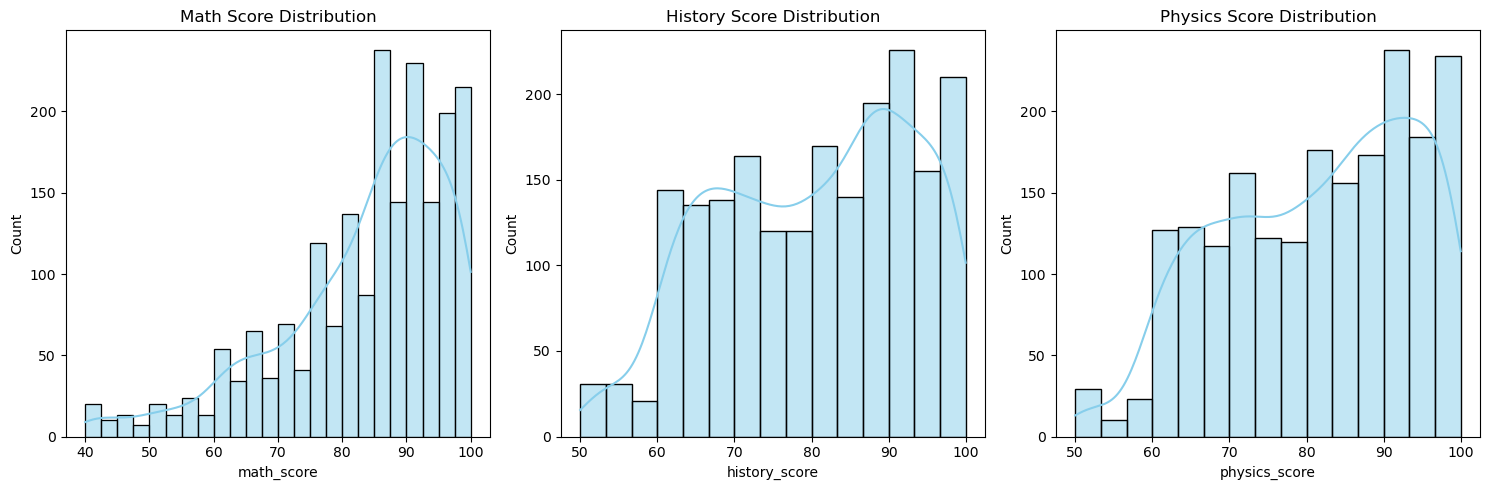

In [16]:
plt.figure(figsize=(15, 5))

for i, subject in enumerate(['math_score','history_score','physics_score']):
    plt.subplot(1, 3, i+1)
    sns.histplot(df[subject], kde=True, color='skyblue')
    plt.title(f'{subject.replace("_", " ").title()} Distribution')

plt.tight_layout()
plt.show()

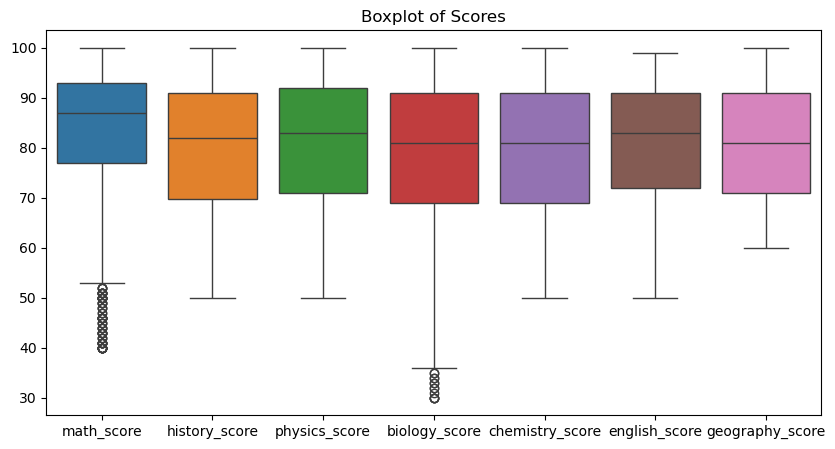

In [26]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[['math_score','history_score','physics_score','biology_score','chemistry_score','english_score','geography_score']])
plt.title('Boxplot of Scores')
plt.show()